In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
import urllib.parse

In [8]:
username = 'root'
password = '123@123'
safe_password = urllib.parse.quote_plus(password)
host = 'localhost'
port = '3306'
database_dwh = 'coffeeshop_dwh'

In [ ]:
# 1. Load data from data warehouse
engine = create_engine(f"mysql+pymysql://{username}:{safe_password}@{host}:{port}/{database_dwh}")

query = "SELECT * FROM fact_sales"
df = pd.read_sql(query, engine)

In [16]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_id    149116 non-null  int64  
 1   Transaction_date  149116 non-null  object 
 2   Transaction_time  149116 non-null  str    
 3   Transaction_qty   149116 non-null  int64  
 4   Store_id          149116 non-null  int64  
 5   Store_location    149116 non-null  str    
 6   Product_id        149116 non-null  int64  
 7   Unit_price        149116 non-null  float64
 8   Product_category  149116 non-null  str    
 9   Product_type      149116 non-null  str    
 10  Product_detail    149116 non-null  str    
dtypes: float64(1), int64(4), object(1), str(5)
memory usage: 12.5+ MB


,Transaction_id,Transaction_date,Transaction_time,Transaction_qty,Store_id,Store_location,Product_id,Unit_price,Product_category,Product_type,Product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [27]:
df['Transaction_datetime'] = pd.to_datetime(df['Transaction_date'].astype(str) + ' ' + df['Transaction_time'])
cols = [col for col in df.columns if col != 'Transaction_datetime']
cols.insert(3, 'Transaction_datetime')
df = df[cols]

df['Revenue'] = df['Transaction_qty'] * df['Unit_price']

df['Day_of_Week'] = pd.to_datetime(df['Transaction_date']).dt.day_name()
cols = [col for col in df.columns if col != 'Day_of_Week']
cols.insert(4, 'Day_of_Week')
df = df[cols]

df.head()

,Transaction_id,Transaction_date,Transaction_time,Transaction_datetime,Day_of_Week,Transaction_qty,Store_id,Store_location,Product_id,Unit_price,Product_category,Product_type,Product_detail,Revenue
0,1,2023-01-01,07:06:11,2023-01-01 07:06:11,Sunday,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2023-01-01,07:08:56,2023-01-01 07:08:56,Sunday,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2023-01-01,07:14:04,2023-01-01 07:14:04,Sunday,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2023-01-01,07:20:24,2023-01-01 07:20:24,Sunday,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2023-01-01,07:22:41,2023-01-01 07:22:41,Sunday,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2



##### 1. Dòng sản phẩm nào bán chạy nhất và mang lại doanh thu cao nhất ?

In [21]:
print("Total Revenue: ${:,.2f}".format(df['Revenue'].sum()))

Total Revenue: $698,812.33


In [22]:
top_5_products = df.groupby('Product_detail')['Transaction_qty'].sum().sort_values(ascending=False).head(5)
top_5_products

Product_detail
Earl Grey Rg               4708
Dark chocolate Lg          4668
Morning Sunrise Chai Rg    4643
Latte                      4602
Peppermint Rg              4564
Name: Transaction_qty, dtype: int64

In [23]:
top_rev_products = df.groupby('Product_detail')['Revenue'].sum().sort_values(ascending=False).head(5)
top_rev_products

Product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Name: Revenue, dtype: float64

##### 2. Ngày nào trong tuần là đông khách nhất ?

In [26]:
crowed_weekday = df.groupby('Day_of_Week')['Transaction_id'].count().sort_values(ascending=False)
crowed_weekday.head(6)

Day_of_Week
Friday       21701
Thursday     21654
Monday       21643
Wednesday    21310
Tuesday      21202
Sunday       21096
Name: Transaction_id, dtype: int64

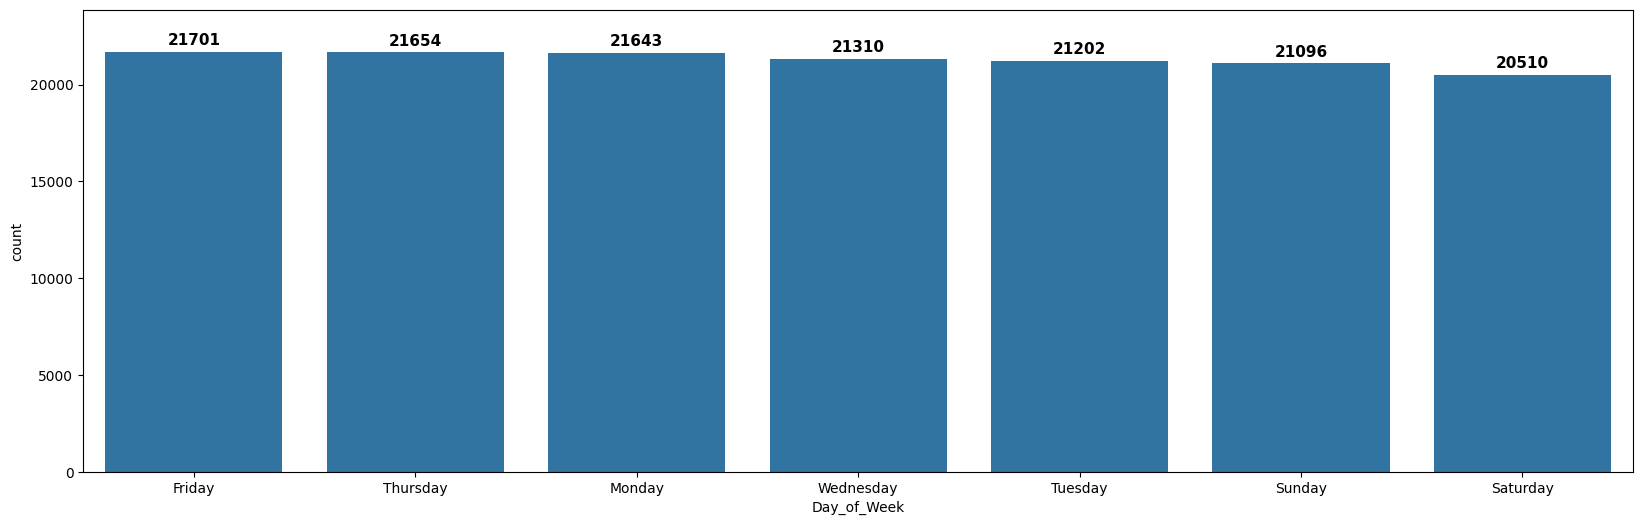

In [ ]:
plt.figure(figsize=(20,6))
ax = sns.countplot(data=df, x='Day_of_Week', order=crowed_weekday.index)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, fontweight='bold')

plt.ylim(0, crowed_weekday.max() * 1.1) 
plt.grid(False)
plt.show()

##### 3. Hóa đơn trung bình của 1 khách hàng là bao nhiêu ?

In [ ]:
average_revenue_per_transaction = df['Revenue'].mean()
print("Average Revenue per Transaction: ${:,.2f}".format(average_revenue_per_transaction))

Average Revenue per Transaction: $4.69


##### 4. Yếu tố thời tiết hoặc vị trí cửa hàng ảnh hưởng như thế nào đến doanh số ?
##### - Vì không có dữ liệu về thời tiết nên chi xét vị trí cửa hàng.

In [ ]:
location_revenue = df.groupby('Store_location')['Revenue'].sum().sort_values(ascending=False)
print("Total Revenue by Store Location:")
print(location_revenue)

Total Revenue by Store Location:
Store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: Revenue, dtype: float64


C:\Users\Minh Duc\AppData\Local\Temp\ipykernel_42532\733288640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=location_revenue.index, y=location_revenue.values, palette='viridis')


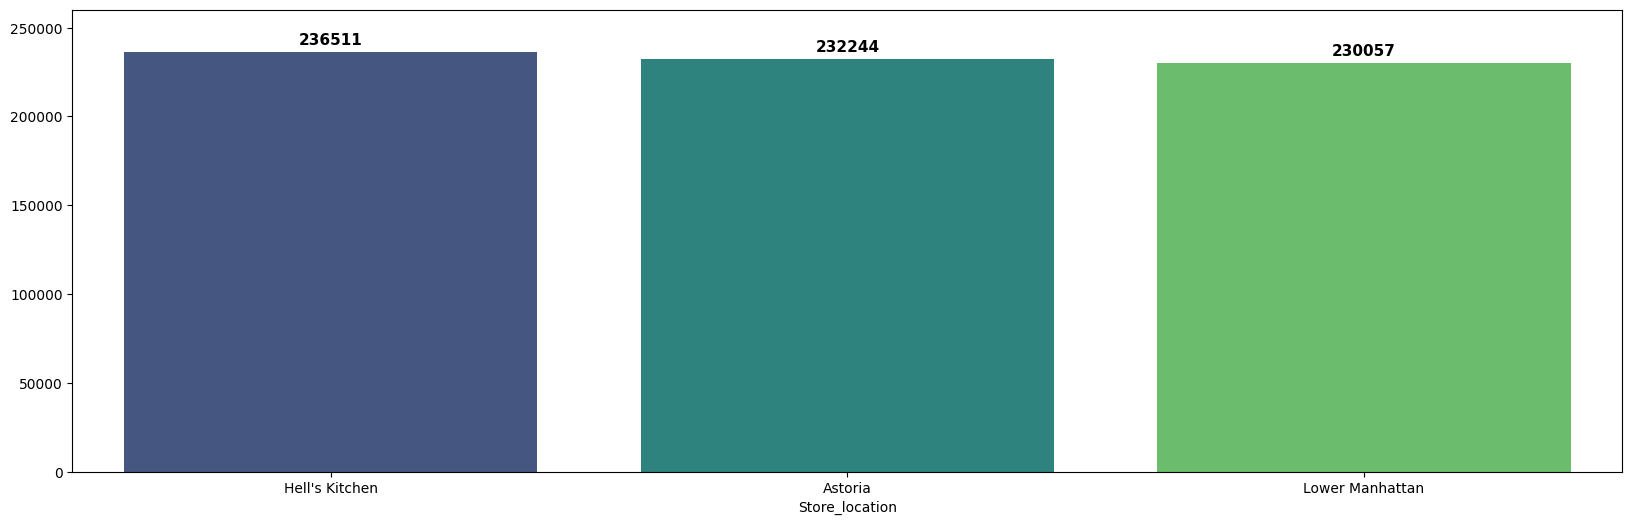

In [ ]:
plt.figure(figsize=(20,6))
ax = sns.barplot(x=location_revenue.index, y=location_revenue.values, palette='viridis')
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, fontweight='bold')
plt.ylim(0, location_revenue.max() * 1.1)
plt.show()

##### 5. Khung giờ cao điểm là khi nào ?

In [ ]:
df['Hour'] = df['Transaction_datetime'].dt.hour
hourly_revenue = df.groupby('Hour')['Revenue'].sum()

print("Hourly Revenue:", hourly_revenue)

Hourly Revenue: Hour
0    698812.33
Name: Revenue, dtype: float64


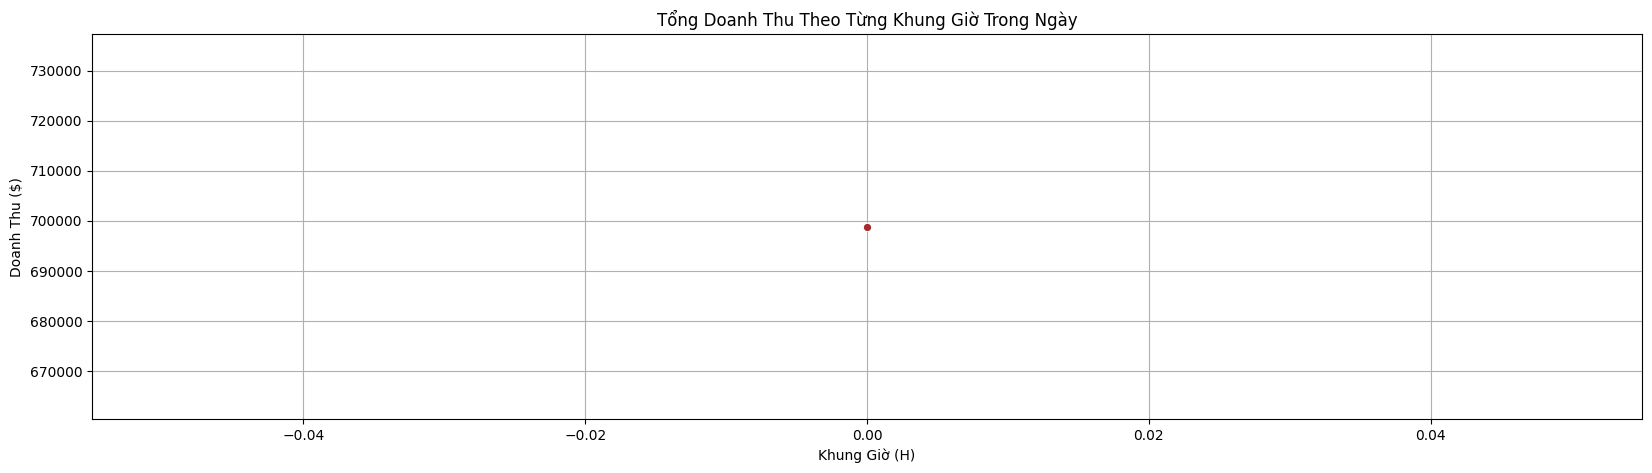

In [ ]:

plt.figure(figsize=(20, 5))
sns.lineplot(x=hourly_revenue.index, y=hourly_revenue.values, marker='o', color='brown')
plt.title('Tổng Doanh Thu Theo Từng Khung Giờ Trong Ngày')
plt.xlabel('Khung Giờ (H)')
plt.ylabel('Doanh Thu ($)')
plt.grid(True)
plt.show()

##### 6. khung giờ cao điểm ở từng cửa hàng có khác nhau không ?

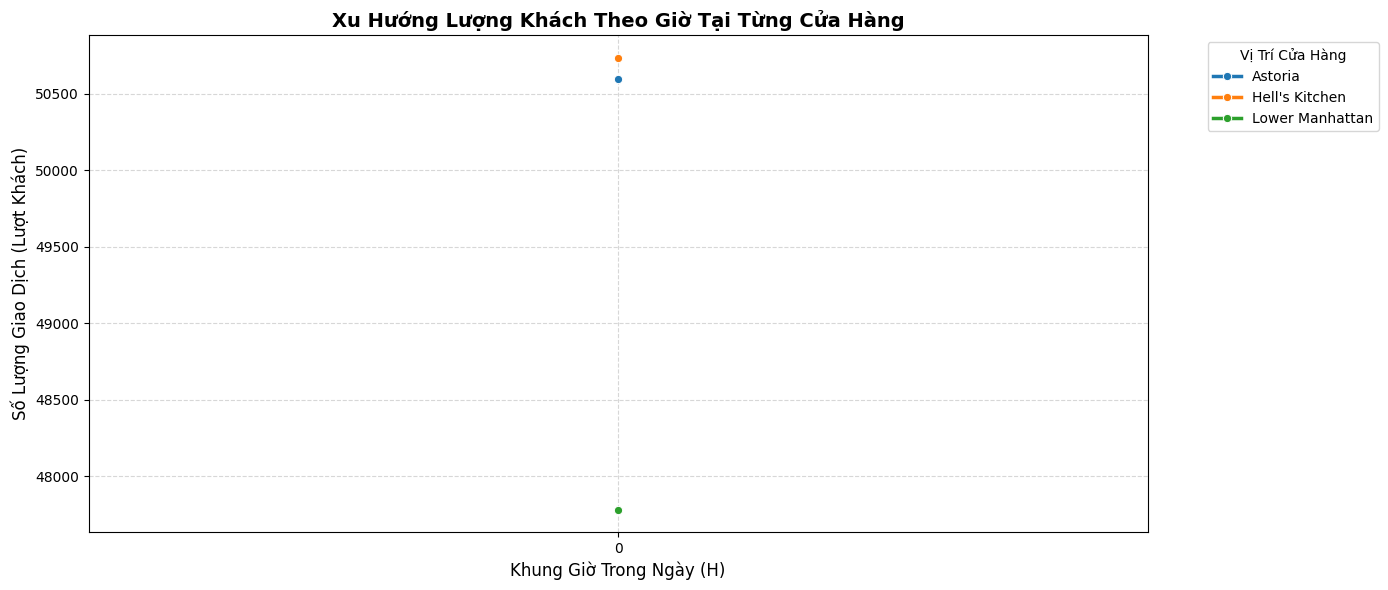

In [ ]:

hourly_store_counts = df.groupby(['Hour', 'Store_location']).size().reset_index(name='transaction_count')

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=hourly_store_counts, 
    x='Hour', 
    y='transaction_count', 
    hue='Store_location', 
    marker='o', 
    linewidth=2.5
)

plt.title('Xu Hướng Lượng Khách Theo Giờ Tại Từng Cửa Hàng', fontsize=14, fontweight='bold')
plt.xlabel('Khung Giờ Trong Ngày (H)', fontsize=12)
plt.ylabel('Số Lượng Giao Dịch (Lượt Khách)', fontsize=12)

plt.xticks(sorted(df['Hour'].unique())) 

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Vị Trí Cửa Hàng', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Actionable Insights